# Stock Market Prediction Using Machine Learning and Ensemble Learning

## Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt



from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme()

## Data Processing


In [2]:
# Ticker = input(print('Enter Ticker: '))
Ticker ='AAPL'

df = yf.download(Ticker,'2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201431,72.239965,70.503569,70.754036,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


In [4]:
df['Target'] = df['Close'].shift(-1)
df.head()

Price,Close,High,Low,Open,Volume,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,71.630646
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,72.201431
2020-01-06,72.201431,72.239965,70.503569,70.754036,118387200,71.861847
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,73.017845
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200,74.568794


In [5]:

df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()


df['Volatility'] = df['Close'].rolling(10).std()


df['Daily_Return'] = df['Close'].pct_change()

In [6]:
df.dropna(axis=0,inplace=True)

In [7]:
df.describe()

Price,Close,High,Low,Open,Volume,Target,MA_10,MA_50,Volatility,Daily_Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
count,1560.000000,1560.000000,1560.000000,1560.000000,1.560000e+03,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000
mean,174.164389,175.932446,172.224802,173.997431,7.931828e+07,174.321413,173.469794,170.824823,3.656989,0.001243
std,52.314490,52.648584,51.924489,52.242375,4.652364e+07,52.360538,51.984147,51.171416,2.090717,0.019191
min,54.163715,55.160713,51.324811,55.059324,1.791060e+07,54.163715,58.871318,65.185128,0.578254,-0.128647
25%,138.721802,140.438717,136.173468,138.661193,4.860410e+07,138.769421,139.129074,138.035961,2.211571,-0.007966
50%,168.926888,170.523846,167.385279,168.704298,6.628380e+07,168.954956,168.755293,165.321680,3.166085,0.001165
75%,212.930172,214.920542,210.818598,212.930452,9.400258e+07,212.989735,211.811008,209.466156,4.623870,0.010984
max,312.510010,313.260010,309.570007,310.679993,4.016932e+08,312.510010,304.300000,273.862288,19.875921,0.153288


In [8]:
df.isnull().sum()


Price         Ticker
Close         AAPL      0
High          AAPL      0
Low           AAPL      0
Open          AAPL      0
Volume        AAPL      0
Target                  0
MA_10                   0
MA_50                   0
Volatility              0
Daily_Return            0
dtype: int64

## Variables

In [9]:
target = df[['Target']]
features = df[['Close','Volume','High','Low','Open',
         'MA_10','MA_50',
         'Volatility','Daily_Return']]

## Standardization


In [10]:
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(target)


In [11]:
scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(features)

## Train_Test

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y_scaled,test_size = 0.2,shuffle = False)

## Model-1 Regression

In [13]:
model = LinearRegression()

In [14]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
R_Squared = model.score(x_train, y_train)
Bias = model.intercept_[0]


summary = pd.DataFrame({
    'Feature': ['R-Squared', 'Bias (Intercept)'],
    'Value': [R_Squared, Bias]
})

summary

,Feature,Value
0,R-Squared,0.995821
1,Bias (Intercept),-0.001384


In [16]:
y_pred = model.predict(x_test)

y_act = scaler_y.inverse_transform(y_pred)

y_test_act = scaler_y.inverse_transform(y_test)

## Model 2 Random Forest

In [17]:
y_rf = df['Target']

## Train_Test

In [18]:
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_scaled,y_rf,test_size=0.2,shuffle=False)

In [19]:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42
)

rf.fit(x_train_rf,y_train_rf)

rf_pred = rf.predict(x_test_rf)

## Ensemble Learning

In [20]:
ensemble_pred = (0.8 * y_pred +0.2 * rf_pred.reshape(-1,1))

##  Error Calculation

In [21]:
comparison = pd.DataFrame({'Actual': y_test_act.flatten(),'Linear Regression': y_act.flatten(),'Random Forest': rf_pred.flatten()})

comparison['Ensemble'] = 0.8 * comparison['Linear Regression'] + 0.2 * comparison['Random Forest']

comparison['LR_Error'] = comparison['Actual'] - comparison['Linear Regression']
comparison['RF_Error'] = comparison['Actual'] - comparison['Random Forest']
comparison['Ensemble_Error'] = comparison['Actual'] - comparison['Ensemble']

comparison['LR_Smooth_Error'] = comparison['LR_Error'].rolling(10).mean()
comparison['RF_Smooth_Error'] = comparison['RF_Error'].rolling(10).mean()
comparison['Ensemble_Smooth_Error'] = comparison['Ensemble_Error'].rolling(10).mean()

In [22]:
comparison['Date'] = df.index[-len(comparison):]

lr_rmse = np.sqrt(mean_squared_error(comparison['Actual'], comparison['Linear Regression']))
lr_mae = mean_absolute_error(comparison['Actual'], comparison['Linear Regression'])

rf_rmse = np.sqrt(mean_squared_error(comparison['Actual'], comparison['Random Forest']))
rf_mae = mean_absolute_error(comparison['Actual'], comparison['Random Forest'])

ensemble_rmse = np.sqrt(mean_squared_error(comparison['Actual'], comparison['Ensemble']))
ensemble_mae = mean_absolute_error(comparison['Actual'], comparison['Ensemble'])

In [23]:
metrics = pd.DataFrame({'Model':['Linear Regression','Random Forest','Ensemble'],'RMSE':[lr_rmse,rf_rmse,ensemble_rmse],'MAE':[lr_mae,rf_mae,ensemble_mae]})

In [24]:
metrics

,Model,RMSE,MAE
0,Linear Regression,4.387702,2.964623
1,Random Forest,16.153390,10.863157
2,Ensemble,5.469537,3.955042


In [25]:
direction_acc = np.mean(np.sign(comparison['Actual'].diff()[1:]) == np.sign(comparison['Ensemble'].diff()[1:])) * 100

print(f'Direction Accuracy: {direction_acc:.2f}%')

Direction Accuracy: 52.73%


## Chart

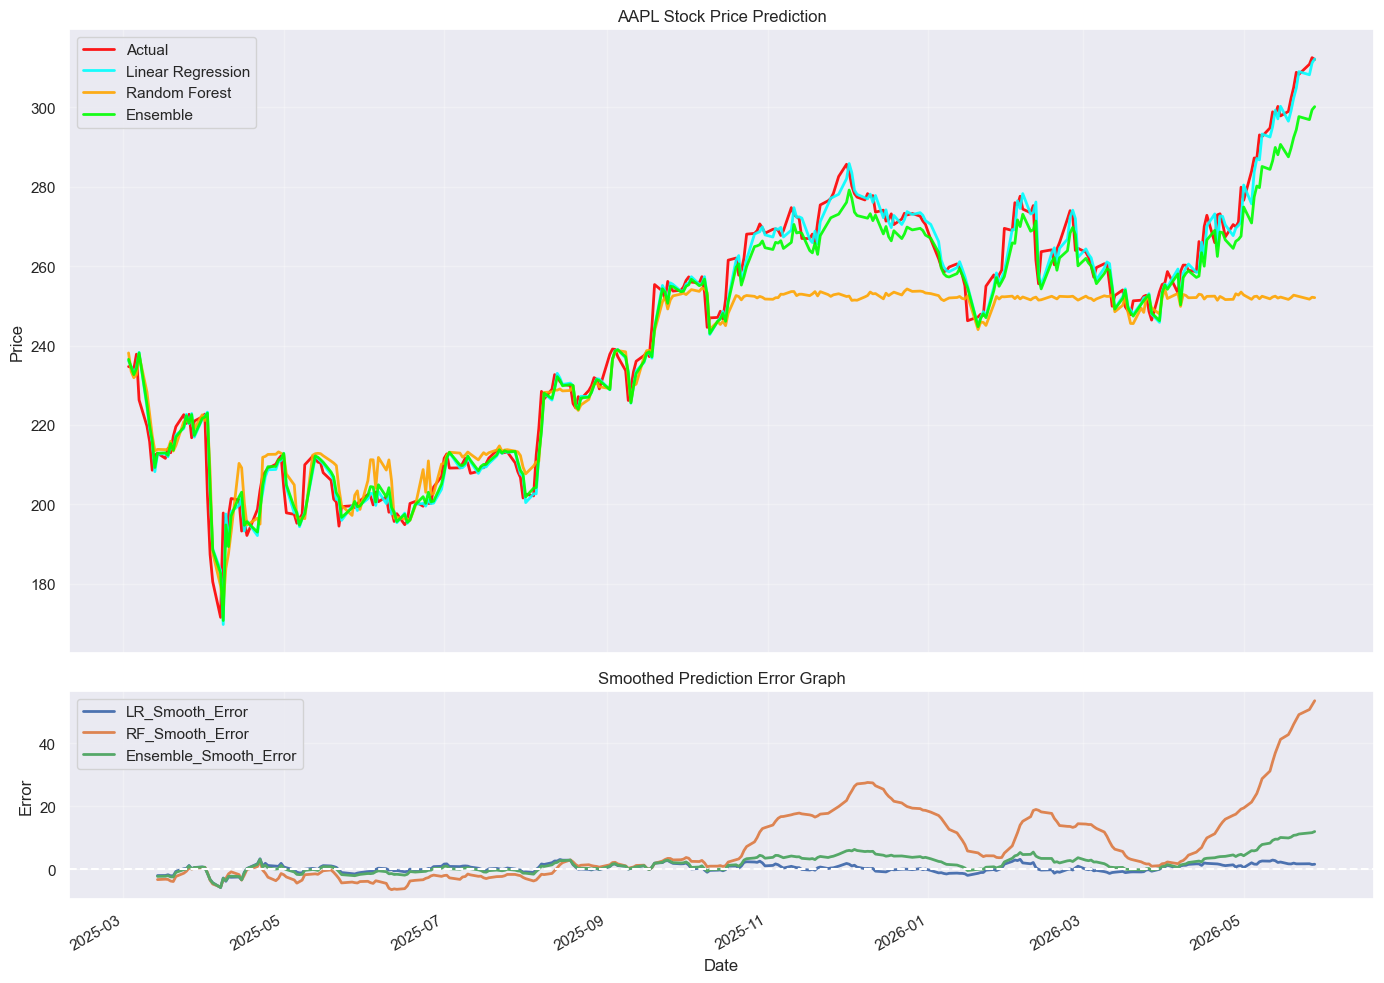

In [26]:
fig, axes = plt.subplots(2,1,figsize=(14,10),sharex=True,gridspec_kw={'height_ratios':[3,1]})

comparison.plot(x='Date',y=['Actual','Linear Regression','Random Forest','Ensemble'],ax=axes[0],linewidth=2,alpha=0.9,color=['red','cyan','orange','lime'],title=f'{Ticker} Stock Price Prediction')

axes[0].set_ylabel('Price')
axes[0].grid(alpha=0.3)


comparison.plot(x='Date',y=['LR_Smooth_Error','RF_Smooth_Error','Ensemble_Smooth_Error'],ax=axes[1],linewidth=2,title='Smoothed Prediction Error Graph')
axes[1].axhline(y=0,linestyle='--')
axes[1].set_ylabel('Error')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()